In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("cleaned_ph_2024_2025_daily.csv")
df = df.sort_values('Date')
df.head()




,county,sitename,Date,pm2.5,pm10,no,no2,nox,co,so2,o3,AQI,status
0,BARMM,Cotabato City,2024-01-01,18.467671,40.018582,11.540543,23.019358,17.037213,0.753852,6.030623,25.886878,62.9,acutely unhealthy
3655,NCR,Caloocan,2024-01-01,36.476926,79.280763,23.782652,45.514620,36.125558,1.042155,22.771093,57.798794,108.2,emergency
64328,Region VI (Western Visayas),Roxas,2024-01-01,2.122753,27.630327,6.040049,26.812233,18.814230,0.681418,8.416128,50.939842,7.6,good
63597,Region VI (Western Visayas),Passi,2024-01-01,8.479382,16.915759,3.556227,10.481496,7.723114,0.186022,2.673401,34.372347,36.6,unhealthy for sensitive group
88451,Region X (Northern Mindanao),Malaybalay,2024-01-01,22.069719,48.516969,11.906253,32.312534,23.099007,0.707825,2.003601,30.099379,72.4,acutely unhealthy


In [3]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['AQI']
X=df[features].shift(1)
y=df[status]  




In [4]:
unique_dates = df['Date'].unique()
split_idx = int(len(unique_dates) * 0.8)
train_dates = unique_dates[:split_idx]

df_train = df[df['Date'].isin(train_dates)].copy()
df_test = df[~df['Date'].isin(train_dates)].copy()



In [5]:
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

window=15

def create_sequences_by_station(dataframe, feature_cols, window_size=15):
    X_seq, y_seq = [], []
    # Group by station name to keep timelines fully isolated
    for station, group in dataframe.groupby('sitename'):
        group_sorted = group.sort_values('Date')
        group_features = group_sorted[feature_cols].values
        group_targets = group_sorted['AQI'].values
            
        if len(group_sorted) > window_size:
            for i in range(len(group_sorted) - window_size):
                X_seq.append(group_features[i : (i + window_size)])
                y_seq.append(group_targets[i + window_size])
                
    return np.array(X_seq), np.array(y_seq)

# Build valid 3D shapes representing (Samples, 10 Hours, 8 Features)
X_train_seq, y_train_seq = create_sequences_by_station(df_train, features, window_size=window)
X_test_seq, y_test_seq = create_sequences_by_station(df_test, features, window_size=window)

print("Clean Train Sequence Shape:", X_train_seq.shape)
print("Clean Test Sequence Shape:", X_test_seq.shape)

Clean Train Sequence Shape: (80798, 15, 8)
Clean Test Sequence Shape: (18744, 15, 8)


In [6]:
X_train_seq, y_train_seq=np.array(X_train_seq),np.array(y_train_seq)

In [7]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(window, 8)), 
    
    # First GRU layer 
    layers.GRU(128, return_sequences=True),
    #layers.BatchNormalization(), 
    layers.Dropout(0.3),
    
    # First GRU layer 
    layers.GRU(64, return_sequences=True),
    #layers.BatchNormalization(), 
    layers.Dropout(0.2),
    

    # Third GRU layer
    layers.GRU(32),
    #layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(16, activation='relu'),
    
    # Output Layer
    layers.Dense(1, activation='linear')
])

In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae','mse'

    ]
)

In [9]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='PhT_best_model_rf_regressor.keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

In [10]:
model.fit(
X_train_seq, np.log1p(y_train_seq),
epochs=100,
batch_size=256,
shuffle=True,
validation_data=[X_test_seq,np.log1p(y_test_seq)],
validation_split=0.2,
verbose=1,
callbacks=my_callbacks

)#training nn

Epoch 1/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 52s 125ms/step - loss: 0.5403 - mae: 0.5403 - mse: 1.1056 - val_loss: 0.1075 - val_mae: 0.1075 - val_mse: 0.0357 - learning_rate: 0.0010
Epoch 2/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - loss: 0.2288 - mae: 0.2288 - mse: 0.0949 - val_loss: 0.1020 - val_mae: 0.1020 - val_mse: 0.0311 - learning_rate: 0.0010
Epoch 3/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 0.2083 - mae: 0.2083 - mse: 0.0793 - val_loss: 0.0984 - val_mae: 0.0984 - val_mse: 0.0277 - learning_rate: 0.0010
Epoch 4/100
 53/316 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - loss: 0.2011 - mae: 0.2011 - mse: 0.0726

KeyboardInterrupt: 

In [11]:
best_model=tf.keras.models.load_model("PhT_best_model_rf_regressor.keras")
nn_pseudo_labels = best_model.predict(X_train_seq)
y_pseudo_train = nn_pseudo_labels.flatten()



#Flatten properly aligned 3D sequences into a 2D format for the Random Forest
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0],-1)
X_test_flat_sequences =X_test_seq.reshape(X_test_seq.shape[0],-1)

true_scale_pseudo = np.expm1(y_pseudo_train)
weights = np.where(true_scale_pseudo > 100, 5.0, 1.0)
#Train the student Regressor with proper initialization constraints
print("Training Optimized Student Random Forest...")
rf_distilled = RandomForestRegressor(
    n_estimators=300,       # Streamlines tree generation
    #max_depth=40,          # Limits float split depth to run efficiently
    n_jobs=-1,             # Runs processing in parallel across all CPU cores
    random_state=42,
    max_features='sqrt',
    bootstrap=False
)
rf_distilled.fit(X_train_flat, y_pseudo_train,sample_weight=weights)

#Predict and evaluate performance metrics
y_pred_rf = rf_distilled.predict(X_test_flat_sequences)
y_pred_rf=np.expm1(y_pred_rf)

print("\n--- Corrected Distilled Random Forest Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_seq, y_pred_rf):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_seq, y_pred_rf):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_seq, y_pred_rf)):.4f}")
print(f"R-squared (R2) Variance Score: {r2_score(y_test_seq, y_pred_rf):.4f}")

2525/2525 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step
Training Optimized Student Random Forest...

--- Corrected Distilled Random Forest Regression Performance ---
Mean Absolute Error (MAE): 5.5516
Mean Squared Error (MSE): 71.5713
Root Mean Squared Error (RMSE): 8.4600
R-squared (R2) Variance Score: 0.8949


In [ ]:
print(pd.Series(y_pseudo_train).describe())

count    14200.000000
mean         4.116416
std          0.211601
min          3.758507
25%          3.919157
50%          4.081017
75%          4.298835
max          4.579437
dtype: float64


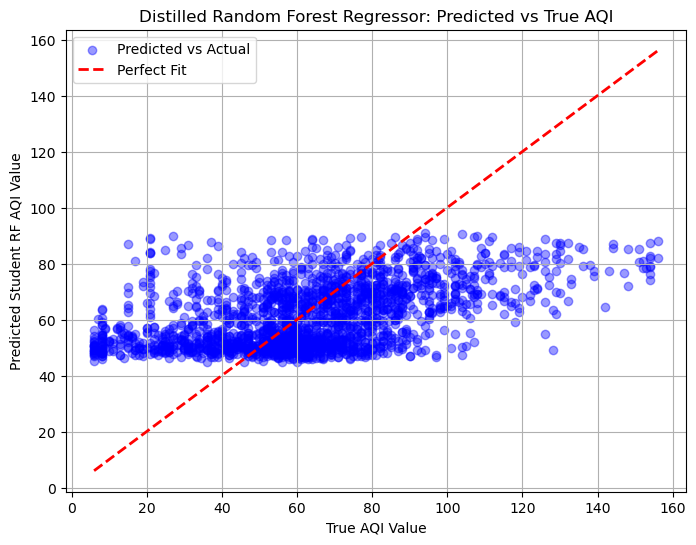

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_seq[:2000], y_pred_rf[:2000], alpha=0.4, color='b', label='Predicted vs Actual')

# Plot accurate perfect diagonal trendline boundary
perfect_line = [min(y_test_seq), max(y_test_seq)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('True AQI Value')
plt.ylabel('Predicted Student RF AQI Value')
plt.title('Distilled Random Forest Regressor: Predicted vs True AQI')
plt.legend()
plt.grid(True)
plt.savefig('PhT_regression_fit_perf.png')

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# 1. Flatten the 3D AUGMENTED sequence array into 2D matrices for Random Forest
# CHANGED: X_train_res instead of X_train_seq
X_train_flat = X_train_res.reshape(X_train_res.shape[0], -1)
X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

# 2. Define the parameter search space for the Random Forest Regressor
param_dist_rf_reg = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap': [True]
}

# 3. Initialize the baseline RandomForestRegressor
rf_reg_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# 4. Configure the Randomized Search
print("Starting Hyperparameter Tuning for Random Forest Regressor...")
#rf_reg_search = RandomizedSearchCV(
    estimator=rf_reg_base,
    param_distributions=param_dist_rf_reg,
    n_iter=10, 
    cv=3, 
    scoring='neg_mean_absolute_error', 
    random_state=42,
    n_jobs=-1
)

# 5. Fit the search on the correctly sized 2D flattened data and Teacher's continuous pseudo-labels
rf_reg_search.fit(X_train_flat, y_pseudo_train)

# 6. Extract and print the best model configuration
print("\n✅ Best Random Forest Regressor Parameters Found:")
print(rf_reg_search.best_params_)

best_rf_reg = rf_reg_search.best_estimator_

# 7. Generate predictions using the optimized regressor
y_pred_rf_reg = best_rf_reg.predict(X_test_flat)

# 8. Evaluate performance metrics
print("\n--- Tuned Distilled Random Forest Regressor Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_seq, y_pred_rf_reg):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_seq, y_pred_rf_reg):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_seq, y_pred_rf_reg)):.4f}")
print(f"R-squared (R2) Score: {r2_score(y_test_seq, y_pred_rf_reg):.4f}")

NameError: name 'X_train_res' is not defined